In [1]:
import numpy as np

def jacobi(A, b, x0, tol, max_its): #
    n = len(b)
    x = x0.copy().astype(float) #defining the variable type as a float prevents calculation issues down the line
    error_history = []
    
    for k in range(max_its): #This is the loop that repeats the refinement process multiple times to get the guess closer to the actual answer 
        x_new = np.zeros_like(x)
        for i in range(n): #This is the loop that first isolates the variable, and then updates each individual variable one by one
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        
        error = np.linalg.norm(x_new - x, ord=np.inf) #When I consulted Stack Overflow and Gemini about an plotting issue, it told me to add this so it calculates the single largest change made to any variable in that round to be plotted later.
        error_history.append(error)
        
        if error < tol:
            return x_new, k + 1, error_history
        x = x_new
    return x, max_its, error_history

def gauss_seidel(A, b, x0, tol, max_its):
    n = len(b)
    x = x0.copy().astype(float)
    error_history = []
    
    for k in range(max_its):
        x_old = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x[j] for j in range(i))
            s2 = sum(A[i][j] * x_old[j] for j in range(i + 1, n))
            x[i] = (b[i] - s1 - s2) / A[i][i]
        
        error = np.linalg.norm(x - x_old, ord=np.inf)
        error_history.append(error)
        
        if error < tol:
            return x, k + 1, error_history
    return x, max_its, error_history

#Input the given arrays for the problem
A = np.array([[3, -0.1, -0.2],
              [0.1, 7, -0.3],
              [0.3, -0.2, 10]], dtype=float)
b = np.array([7.85, -19.3, 71.4])
x0 = np.zeros(3)
tols = [1e-3, 1e-6, 1e-9] #This is for each tolerance from 10-3, 10-6, 10-9

all_errors = {}

print(f"{'Method':<15} ; {'Tolerance':<10} ; {'Iterations':<10}") #Used Gemini to see how to make the data presentation cleaner in table form
print("-" * 45)

for t in tols: 
    #This is the call for Jacobi
    sol_j, it_j, err_j = jacobi(A, b, x0, t, 100)
    all_errors[f'Jacobi_{t}'] = err_j
    print(f"{'Jacobi':<15} | {t:<10} | {it_j:<10}")
    
    #This is the call for gauss seidel
    sol_g, it_g, err_g = gauss_seidel(A, b, x0, t, 100)
    all_errors[f'Gauss-Seidel_{t}'] = err_g
    print(f"{'Gauss-Seidel':<15} | {t:<10} | {it_g:<10}")

Method          ; Tolerance  ; Iterations
---------------------------------------------
Jacobi          | 0.001      | 4         
Gauss-Seidel    | 0.001      | 4         
Jacobi          | 1e-06      | 7         
Gauss-Seidel    | 1e-06      | 5         
Jacobi          | 1e-09      | 9         
Gauss-Seidel    | 1e-09      | 7         


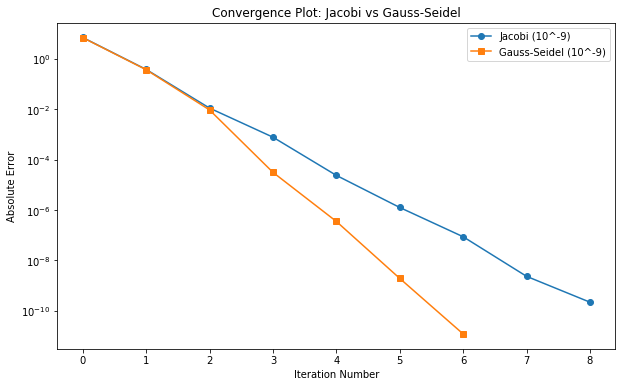

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plotting the convergence for both methods. Used 10^-9 because it ecompasses 10^-6 and 10^-3 as well, so there is no need for an individual plot for each
plt.semilogy(all_errors['Jacobi_1e-09'], label='Jacobi (10^-9)', marker='o')
plt.semilogy(all_errors['Gauss-Seidel_1e-09'], label='Gauss-Seidel (10^-9)', marker='s')

plt.xlabel('Iteration Number')
plt.ylabel('Absolute Error')
plt.title('Convergence Plot: Jacobi vs Gauss-Seidel')
plt.legend()
plt.show()

Judging by the chart and the table, it seems that as the tolerance decreaes in size, the number of iterations needed to get an converagence/answer increases as well. Since the absolute error gets lower and lower, it needs more iterations to converge to the solution within the tolerance. It seem like GS needs less iterations overall however due to the fact it replaces the values back into the loop to solve.